<a href="https://colab.research.google.com/github/HenriqueMFrancisco/PUCRJ_P-S/blob/main/MVP2_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(Henrique_m_FRANCISCO).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Henrique Meirelles Francisco

**Matrícula:**40530010055

**Dataset:** Retail Sales Dataset -  https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset/data

**---OBSERVAÇÕES IMPORTANTES---**



 **------**

# *Descrição do Problema*: ok

***Conjunto de Dados de Vendas no Varejo e Demografia de Clientes:***

Este conjunto de dados sintético foi meticulosamente elaborado para simular um ambiente de varejo dinâmico,
proporcionando um campo ideal para aqueles que desejam aprimorar suas habilidades de análise de dados por meio
 da análise exploratória de dados (EDA). Com foco em vendas no varejo e características dos clientes,
 este conjunto de dados ajudará a identificar padrões intrincados, obter insights e entender melhor o comportamento do cliente.


## Hipóteses do Problema


As hipóteses que tracei são as seguintes:

- Como a idade e o gênero do cliente influenciam seu comportamento de compra?
- Quais categorias de produtos têm maior apelo entre os clientes?
- Quais são as relações entre idade, gastos e preferências de produtos?





## Tipo de Problema


Este é um problema de **agrupamento e associação não supervisionado**.

## Seleção de Dados

O Retail Sales Dataset é um conjunto de dados disponível no kaggle.

Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset Retail Sales Dataset contém 1000 linhas com 9 atributos:

1.**Transaction ID**: Um identificador único para cada transação, permitindo rastreamento e referência.

2.**Date**: A data em que a transação ocorreu, fornecendo insights sobre as tendências de vendas ao longo do tempo.

3.**Customer ID**: Um identificador único para cada cliente, permitindo uma análise centrada no cliente.

4.**Gender**: O gênero do cliente (Masculino/Feminino), oferecendo insights sobre padrões de compra baseados em gênero.

5.**Age**: A idade do cliente, facilitando a segmentação e a exploração de influências relacionadas à idade.

6.**Product Category**: A categoria do produto adquirido (por exemplo, Eletrônicos, Roupas, Beleza), ajudando a entender as preferências do produto.

7.**Quantity**: O número de unidades do produto adquirido, contribuindo para insights sobre o volume de compras.

8.**Price per Unit**: O preço de uma unidade do produto, auxiliando nos cálculos relacionados ao gasto total.

9.**Total Amount**: O valor monetário total da transação, demonstrando o impacto financeiro de cada compra.

Cada coluna neste conjunto de dados desempenha um papel fundamental na compreensão da dinâmica das operações de varejo e do comportamento do cliente. Ao explorar e analisar esses atributos, você descobrirá tendências, padrões e correlações que esclarecem a complexa interação entre clientes e produtos no varejo.



# *Importação das Bibliotecas Necessárias e Carga de Dados:* ok

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Retail Sales.

In [ ]:
#importação da biblioteca kaggle
import kagglehub
#importação da biblioteca pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# dataset Download latest version
# Caminho do dataset
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")
print("Caminho para o dataset:", path)
# url do dataset retail_sales_dataset.csv

url_dados = path + "/retail_sales_dataset.csv"
print("URL Dataset: ", url_dados)
# carregamento do dataset
retail_sale = pd.read_csv(url_dados)
# confirma o tipo
print("tipo dataset",type(retail_sale))
# primeiras linhas
print("Primeiras linhas:")
print("-------------------------------------------------")
retail_sale.head()

Caminho para o dataset: /kaggle/input/retail-sales-dataset
URL Dataset:  /kaggle/input/retail-sales-dataset/retail_sales_dataset.csv
tipo dataset <class 'pandas.core.frame.DataFrame'>
Primeiras linhas:
-------------------------------------------------


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Quntidade de Linhas e Colunas:")
retail_sale.shape


Quntidade de Linhas e Colunas:


(1000, 9)

In [ ]:
print("Últimas linhas:")
retail_sale.tail()


Últimas linhas:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [ ]:
# Nome das Colunas do dataset
retail_sale.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [ ]:
# Quantidade de regsistros do datset
retail_sale.count()


,0
Transaction ID,1000
Date,1000
Customer ID,1000
Gender,1000
Age,1000
Product Category,1000
Quantity,1000
Price per Unit,1000
Total Amount,1000


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Retail Sales, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Reatail Sales possui 1000 instâncias (observações).
Os tipos de dados de cada coluna podem ser vistos na execução do código Python abaixo.
São 9 colunas todas obrigatórias.

In [ ]:
print(f"Total de instâncias: {len(retail_sale)}")
print("\nTipos de dados por coluna:")
print(retail_sale.info())

Total de instâncias: 1000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


- **O gráfico abaixo apresenta o número de observações de gênero dos clientes:**

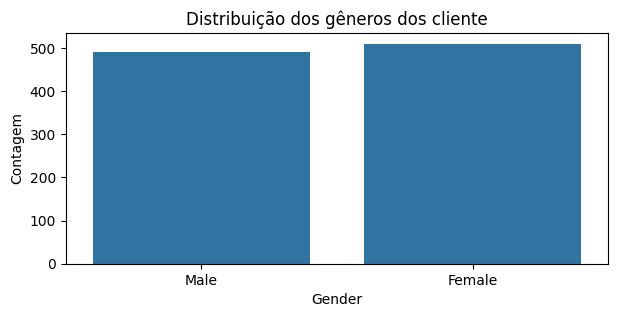

In [ ]:
plt.figure(figsize=(7, 3))
# gráfico de barras simples
sns.countplot(x='Gender', data=retail_sale)
plt.title('Distribuição dos gêneros dos cliente')
plt.xlabel('Gender')
plt.ylabel('Contagem')
plt.show()

- **O gráfico abaixo apresenta o número de observações das categorias de produtos:**

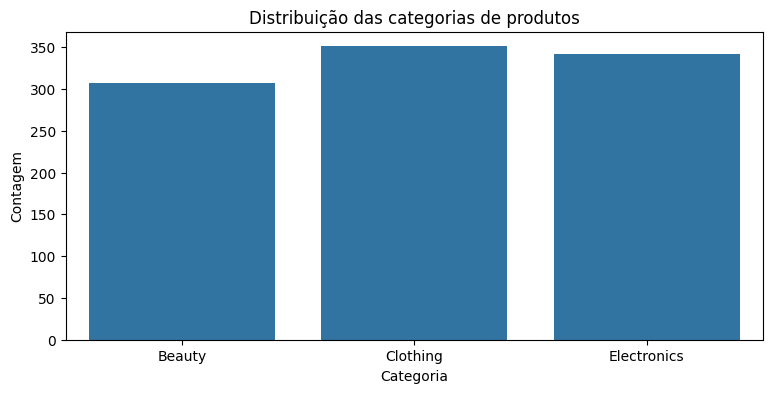

In [ ]:
plt.figure(figsize=(9, 4))
# gráfico de barras simples
sns.countplot(x='Product Category', data=retail_sale)
plt.title('Distribuição das categorias de produtos')
plt.xlabel('Categoria')
plt.ylabel('Contagem')
plt.show()

- **Os gráficos abaixo apresenta o número de observações das idades dos clientes:**

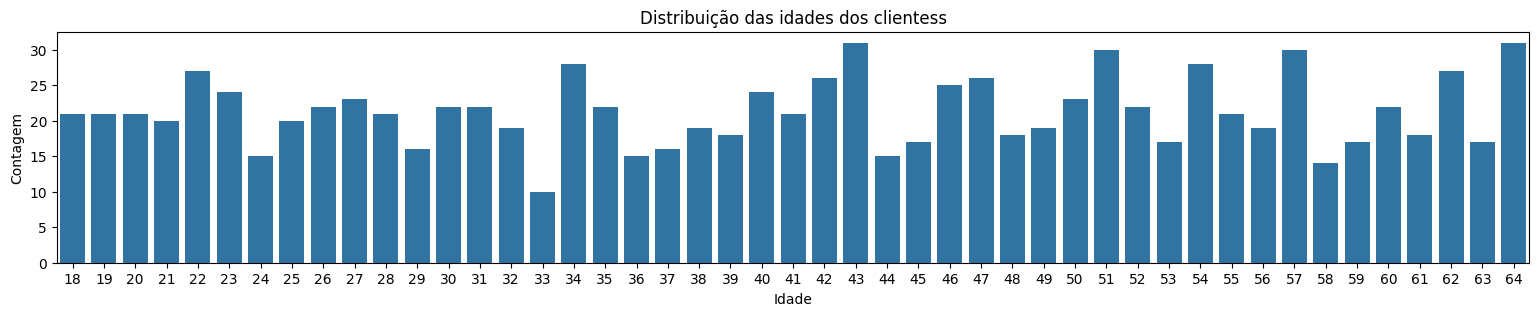

In [ ]:
plt.figure(figsize=(19, 3))
# gráfico de barras simples
sns.countplot(x='Age', data=retail_sale)
plt.title('Distribuição das idades dos clientess')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

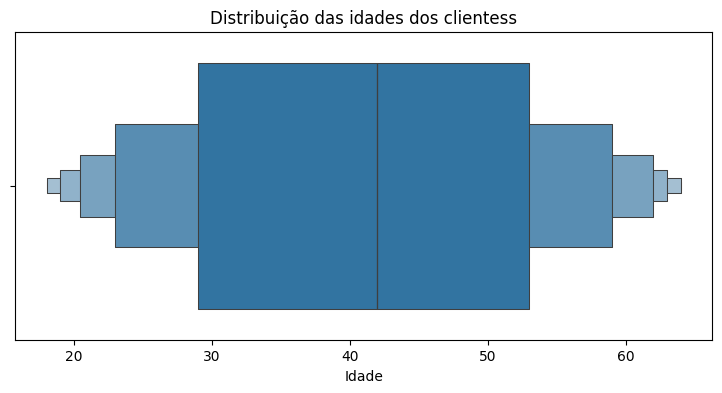

In [ ]:
plt.figure(figsize=(9, 4))
# gráfico de boxeplot
sns.boxenplot(x='Age', data=retail_sale)
plt.title('Distribuição das idades dos clientess')
plt.xlabel('Idade')
#plt.ylabel('Contagem')
plt.show()

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
print("URL Dataset: ", url_dados)
retail_sale.describe()

URL Dataset:  /kaggle/input/retail-sales-dataset/retail_sales_dataset.csv


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
# média dos atributos numéricos do dataset
print("URL Dataset: ", url_dados)
retail_sale.describe().loc['mean']

URL Dataset:  /kaggle/input/retail-sales-dataset/retail_sales_dataset.csv


,mean
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


- **Gráfico boxplot seria interessante para mostrar a média.**
Exemplo da característica AGE:

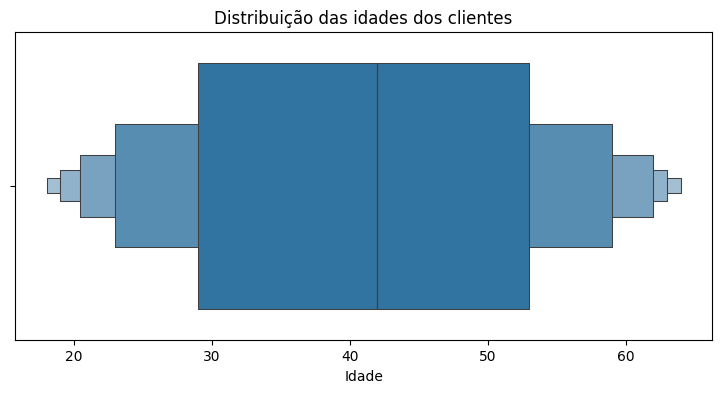

In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?
plt.figure(figsize=(9, 4))
# gráfico de boxeplot
sns.boxenplot(x='Age', data=retail_sale)
plt.title('Distribuição das idades dos clientes')
plt.xlabel('Idade')
#plt.ylabel('Contagem')
plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
print("URL Dataset: ", url_dados)
retail_sale.describe().loc['std']

URL Dataset:  /kaggle/input/retail-sales-dataset/retail_sales_dataset.csv


,std
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

**Kernel Density Estimation (KDE)** é uma técnica estatística utilizada para estimar a função de densidade de probabilidade de uma variável aleatória. Em outras palavras, o KDE fornece uma maneira de suavizar um conjunto de dados, permitindo que os analistas visualizem a distribuição subjacente de uma amostra. Essa abordagem é especialmente útil em situações onde a distribuição dos dados não é conhecida ou quando se deseja uma representação mais intuitiva da densidade dos dados em comparação com um histograma tradicional.

### *Idade*

O histograma mostra a frequencia de ocorrência da idade dos clientes que compraram algum produto.

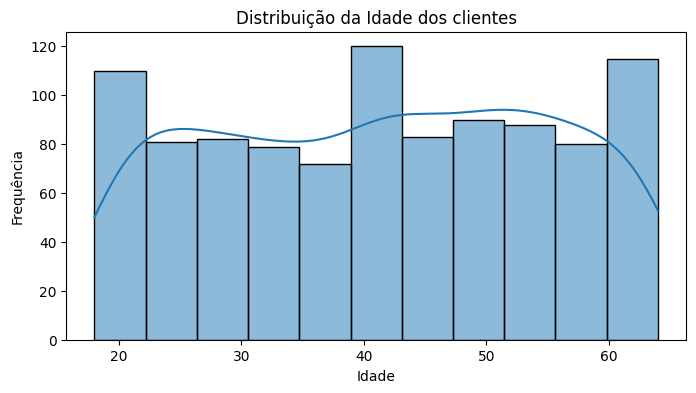

In [ ]:
plt.figure(figsize=(8, 4))
# Histograma da idades dos clientes
sns.histplot(retail_sale['Age'], kde=True)
plt.title('Distribuição da Idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

### *Preço por unidade*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

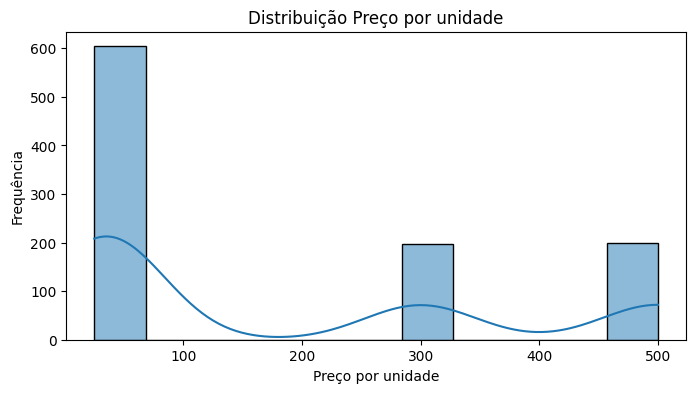

In [ ]:
plt.figure(figsize=(8, 4))
# Histograma do gênero do cliente (Masculino/Feminino)
sns.histplot(retail_sale['Price per Unit'], kde=True)
plt.title('Distribuição Preço por unidade')
plt.xlabel('Preço por unidade')
plt.ylabel('Frequência')
plt.show()

## Boxplot

Um boxplot, ou diagrama de caixa, é uma ferramenta gráfica que resume a distribuição de um conjunto de dados, mostrando sua posição (mediana), dispersão (intervalo interquartil e amplitude), simetria e a presença de valores atípicos (outliers).


### Idade por Gênero


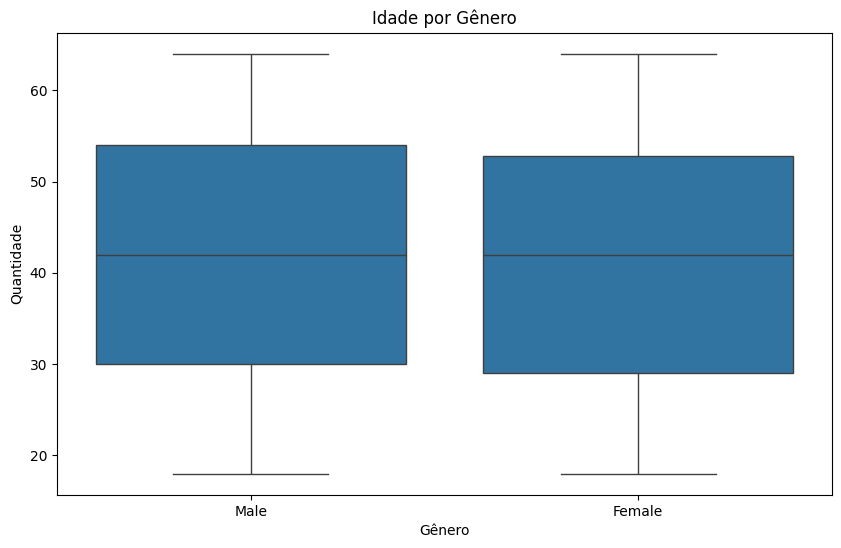

In [ ]:
# Boxplot da Idade por Gênero
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Age', data=retail_sale)
plt.title('Idade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

### Idade por gasto


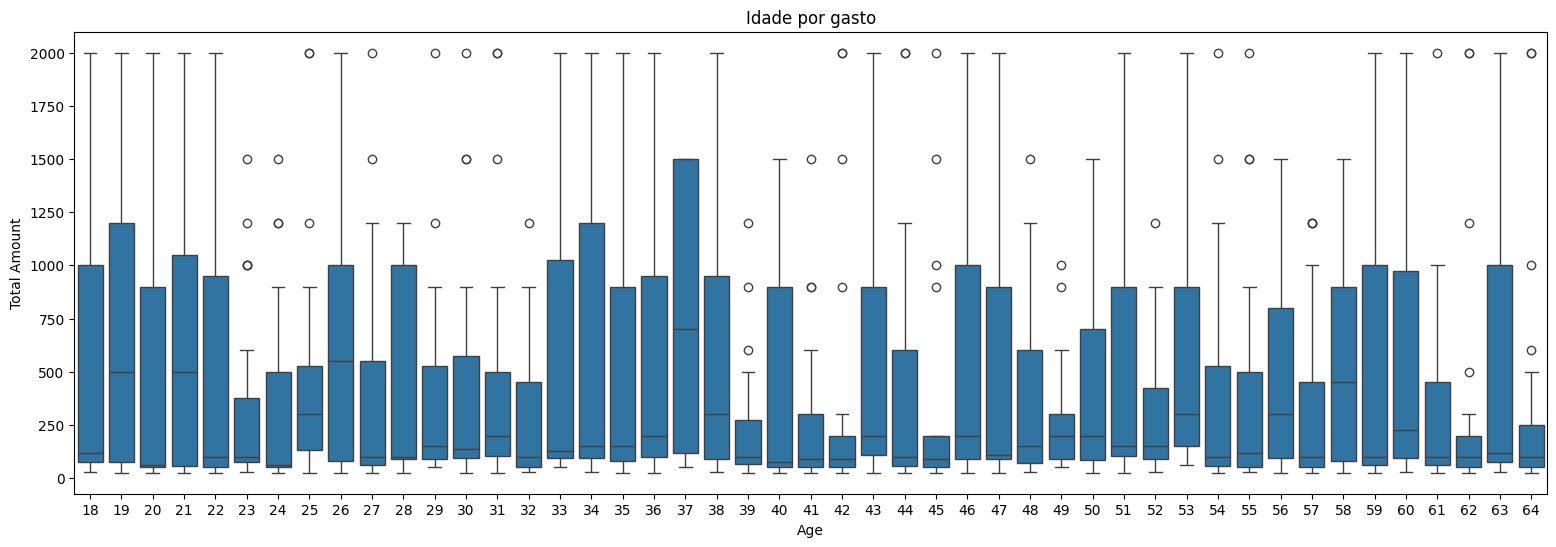

In [ ]:
# Boxplot da Idade por gasto
plt.figure(figsize=(19, 6))
sns.boxplot(x='Age', y='Total Amount', data=retail_sale)
plt.title('Idade por gasto')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.show()

### Idade por categoria


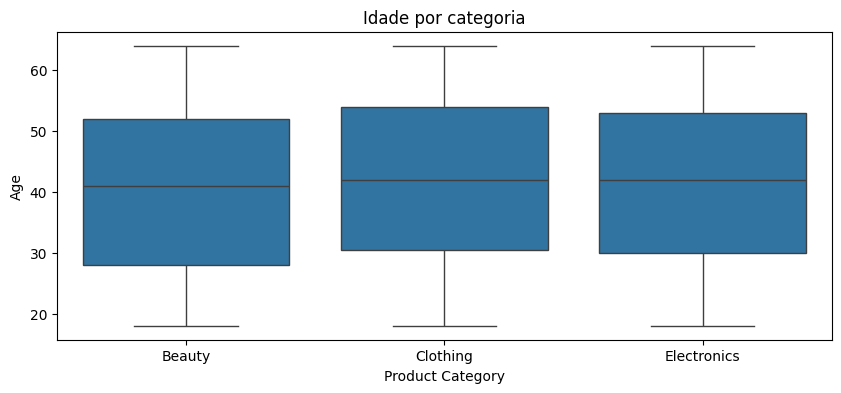

In [ ]:
# Boxplot da quantidade por Gênero
plt.figure(figsize=(10, 4))
sns.boxplot(x='Product Category', y='Age', data=retail_sale)
plt.title('Idade por categoria')
plt.xlabel('Product Category')
plt.ylabel('Age')
plt.show()

### quantidade por Gênero


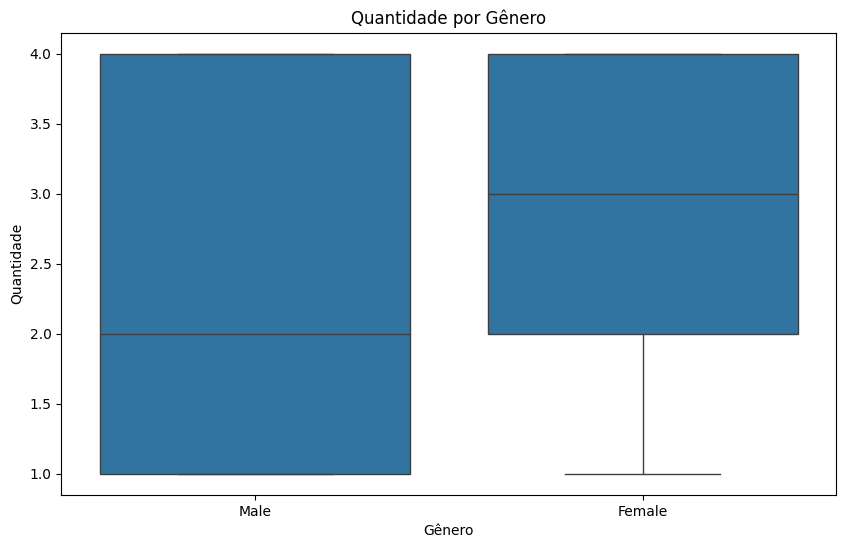

In [ ]:
# Boxplot da quantidade por Gênero
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Quantity', data=retail_sale)
plt.title('Quantidade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

- Acma podemos ver a mediana do gênero Male igual a 2 e o Female um pouco acima de 3.

### Valor total da venda por Categoria de Produto

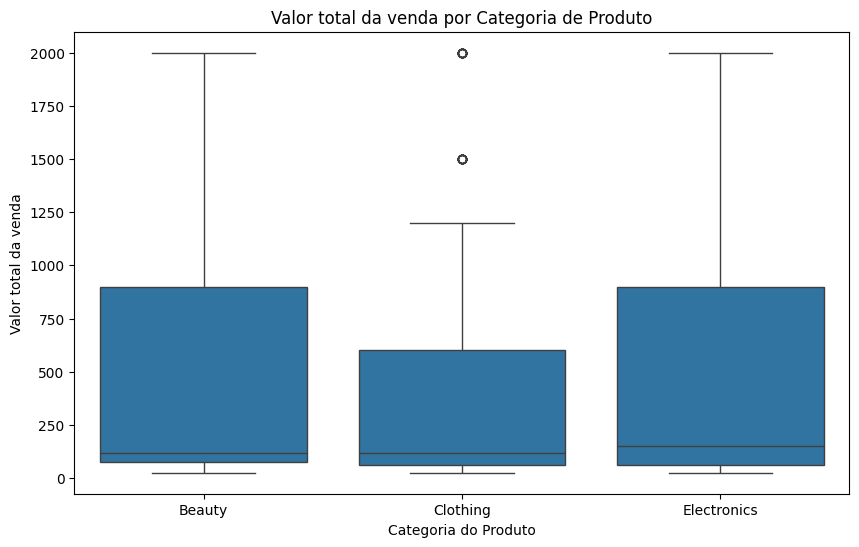

In [ ]:
# Boxplot Valor total da venda por Categoria de Produto
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product Category', y='Total Amount', data=retail_sale)
plt.title('Valor total da venda por Categoria de Produto')
plt.xlabel('Categoria do Produto')
plt.ylabel('Valor total da venda')
plt.show()

Podemos ver acima que categoria Clothing teve dois valores discrepantes (outliers), acima do limite máximo próximo de 1250.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
retail_sale.iloc[:,6:9].corr()



Matriz de Correlação:


,Quantity,Price per Unit,Total Amount
Quantity,1.000000,0.017501,0.373707
Price per Unit,0.017501,1.000000,0.851925
Total Amount,0.373707,0.851925,1.000000


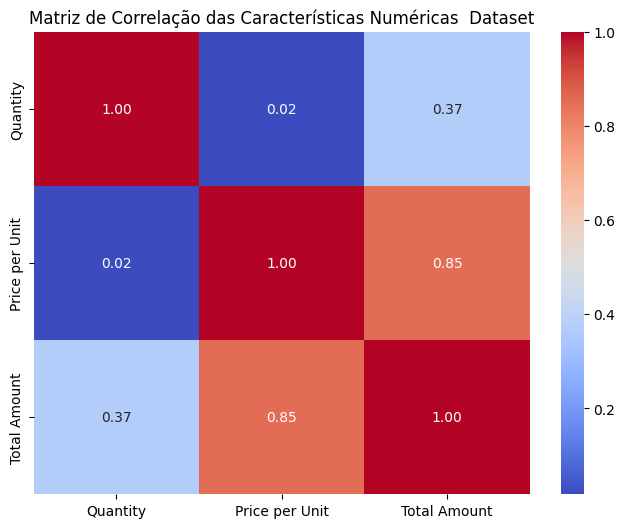

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(retail_sale.iloc[:, 6:9].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas  Dataset')
plt.show()

- Baixa correlação entre a quantidade e o preço por unidade.
- Alta correlação entre preço por unidade e o valor total, o que é esperado.

## Tratamento de Valores Nulos

Como todas as caracerística do dataset Retail Sales são obrigatórias, o dataset não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Retail Sales:")
retail_sale.isnull().sum()

Valores nulos no dataset Retail Sales:


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

- **Dividir o dataset em dois: de teste e de treino.**

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test = train_test_split(retail_sale, test_size=0.3, random_state=42)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")

print("\n--------------------------------------------------\n")

print("Primeira linhas de treinamento:\n ", X_train.head())
print("\n\n\n\n")
print("Primeira linhas de teste: \n",X_test)

Dimensões de X_train: (700, 9)
Dimensões de X_test: (300, 9)

--------------------------------------------------

Primeira linhas de treinamento:
       Transaction ID        Date Customer ID  Gender  Age Product Category  \
541             542  2023-06-17     CUST542  Female   20           Beauty   
440             441  2023-10-10     CUST441    Male   57           Beauty   
482             483  2023-04-25     CUST483    Male   55         Clothing   
422             423  2023-03-08     CUST423  Female   27         Clothing   
778             779  2023-05-05     CUST779  Female   56      Electronics   

     Quantity  Price per Unit  Total Amount  
541         1              50            50  
440         4             300          1200  
482         1              30            30  
422         1              25            25  
778         2             500          1000  





Primeira linhas de teste: 
      Transaction ID        Date Customer ID  Gender  Age Product Category  \
521

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Conclusão

- A análise exploratória do dataset Retail Sales mostrou a importância de se entender os dados antes da modelagem. O dataset se mostrou consitente e bem balanceado e possui carcterística importantes para o entendimentos das correlações entre Idade, Gênero, Tipo de produtos e Valor total de uma compra.
Isto ajudou no processo de validação das hipóteste levantadas:

      1. Como a idade e o gênero do cliente influenciam seu comportamento de compra?

      2. Quais categorias de produtos têm maior apelo entre os clientes?

      3. Quais são as relações entre idade, gastos e preferências de produtos?


- Na preparação dos dados o dataset foi dividido e dados de reinamento e dados de testes.


- No Geral este MVP me ajudou a entender mais profundamente e importância das três primeiras da sete etapas de um projeto de ciência de dados:
    1. Definição do problema;
    2. Coleta e Analise do dados (AED - Analise Exploratória de Dados);
    3. Pré-processamento.
 Ficou claro a importancia e o esforço exigido nestas etapas para o sucesso de um projeto de ciência de dadsos.
   

     

As três hipóteses levantadas foram validadas:


